# Neural representations of MPC solutions via YANNs

---

# Overview

This notebook demonstrates the following:

1. Define a constrained MPC problem  
2. Compute the explicit mp-MPC solution (MPQP)  
3. Construct a neural representation (YANN) of the solution map  
4. Evaluate representation accuracy  

The key idea is that YANNs represent the exact mp-MPC solution map directly, without requiring sampled training data.

---

# Experiment Setup

We consider a linear constrained control system and construct its explicit MPC solution. We then evaluate a neural representation of this solution map.

---

# 1. Environment Setup

In [1]:
import numpy as np
from scipy.linalg import solve_discrete_are
import tensorflow as tf

In [2]:
# mp-mpc dependencies
from ppopt.mpqp_program import MPQP_Program
from ppopt.mp_solvers.solve_mpqp import solve_mpqp, mpqp_algorithm


In [3]:
# project utilities
from utils import make_LQR_MPC_QP
from yann_from_ppopt import *
tf.keras.backend.set_floatx('float64')

# 2. Define MPC System, Constraints, and Objective

In [4]:
# define the linear system
A = np.array([[ 1.0,  1.0], [ 0.0,  1.0]], float)
B = np.array([[ 0.0], [ 1.0]], float)
C = np.array([[ 1.0,  2.0]], float)
D = np.array([[ 0.0]], float)


# define objective weighting matrices
Q = np.array([[ 1.0,  0.0], [ 0.0,  1.0]], float)
R = np.array([[ 0.01]], float)

# define state, input, and output constraints
x_lbound = np.array([-10.0, -10.0], float)
x_ubound = np.array([ 10.0,  10.0], float)
y_lbound = np.array([-25.0], float)
y_ubound = np.array([ 25.0], float)
u_lbound = np.array([-1.0], float)
u_ubound = np.array([ 1.0], float)

# define the terminal set constraints
AT = np.array([
    [ 0.6136,  1.6099],
    [-0.3742, -0.3682],
    [-0.6136, -1.6099],
    [ 0.3742,  0.3682]], float)
bT = np.array([1.0, 1.0, 1.0, 1.0], float)

# use the DARE for terminal penalty matrix
P = solve_discrete_are(A, B, Q, R)

# output and control horizon
N = 10

# 3. Construct mp-MPC (Equivalent mp-QP Formulation)

In [5]:
# generate mp-MPC problem  matrices
Hs, Zs, Ms, Gs, Ws, Ss, CRa, CRb = make_LQR_MPC_QP(A, B, P, Q, R, N,
    np.block([[-np.identity(u_lbound.size, float)],
              [ np.identity(u_ubound.size, float)]]),
    np.block([-u_lbound,  u_ubound]),
    np.block([[-np.identity(x_lbound.size, float)],
              [ np.identity(x_ubound.size, float)], [-C], [ C]]),
    np.block([-x_lbound,  x_ubound, -y_lbound,  y_ubound]),
    np.block([[-np.identity(x_lbound.size, float)],
              [ np.identity(x_ubound.size, float)], [-C], [ C]]),
    np.block([-x_lbound,  x_ubound, -y_lbound,  y_ubound]),
    AT, bT)

# build the corresponding MPQP
prog = MPQP_Program(Gs, Ws, np.zeros((B.shape[1]*N,1), float), Zs, 2.0*Hs, CRa, CRb, Ss)
prog.process_constraints()

# 4. Solve Explicit MPC (mp-MPC)

First region ()
Restricted license - for non-production use only - expires 2026-11-23


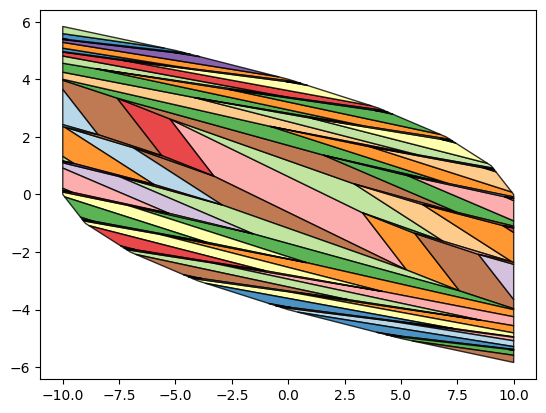

In [6]:
# solve the MPQP
solution_example_1 = solve_mpqp(prog, mpqp_algorithm.graph)
from ppopt.plot import parametric_plot
parametric_plot(solution_example_1)

# 5. Construct YANN Representation of the Solution Map

In [7]:
# Build and print the YANN
model = sol_to_yann(solution_example_1,2)
print(model.summary())

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 2)]          0           []                               
                                                                                                  
 layer1 (Dense)                 (None, 472)          1416        ['input[0][0]']                  
                                                                                                  
 lambda (Lambda)                (None, 472)          0           ['layer1[0][0]']                 
                                                                                                  
 layer2 (Dense)                 (None, 115)          54395       ['lambda[0][0]']                 
                                                                                              

# 6. Evaluation: Compare Against the Original Solution

We evaluate the neural representation by uniformly sampling the state space and comparing outputs against the exact mp-MPC solution map.

In [8]:
np.random.seed(0)

# sample inputs
random_inputs = 0.5 * np.random.rand(10000, 2)

# YANN predictions
output_yann = np.array([model(x.reshape(1, -1)) for x in random_inputs]).reshape(-1, 1)

# exact mp-MPC solution
output_function = np.array([
    solution_example_1.evaluate(x.reshape(2, 1))[0]
    for x in random_inputs
]).reshape(-1, 1)

# error metric
error = np.abs(output_function - output_yann)

print("Max absolute error:", np.max(error))
print("Mean error:", np.mean(error))

Max absolute error: 5.6066262743570405e-14
Mean error: 1.8456054132892642e-14


# Results Interpretation

The maximum deviation between the mp-MPC solution and the neural representation is reported above.

This metric reflects worst-case approximation error across sampled states.

---


# 7. Closed-Loop Trajectory Comparison

We now compare the closed-loop behavior of the exact mp-MPC controller and its YANN representation over **100 random initial conditions**.

Both controllers are simulated on the original system dynamics:

\[
x_{k+1} = A x_k + B u_k
\]

The resulting state trajectories illustrate how closely the neural representation matches the original explicit MPC controller.

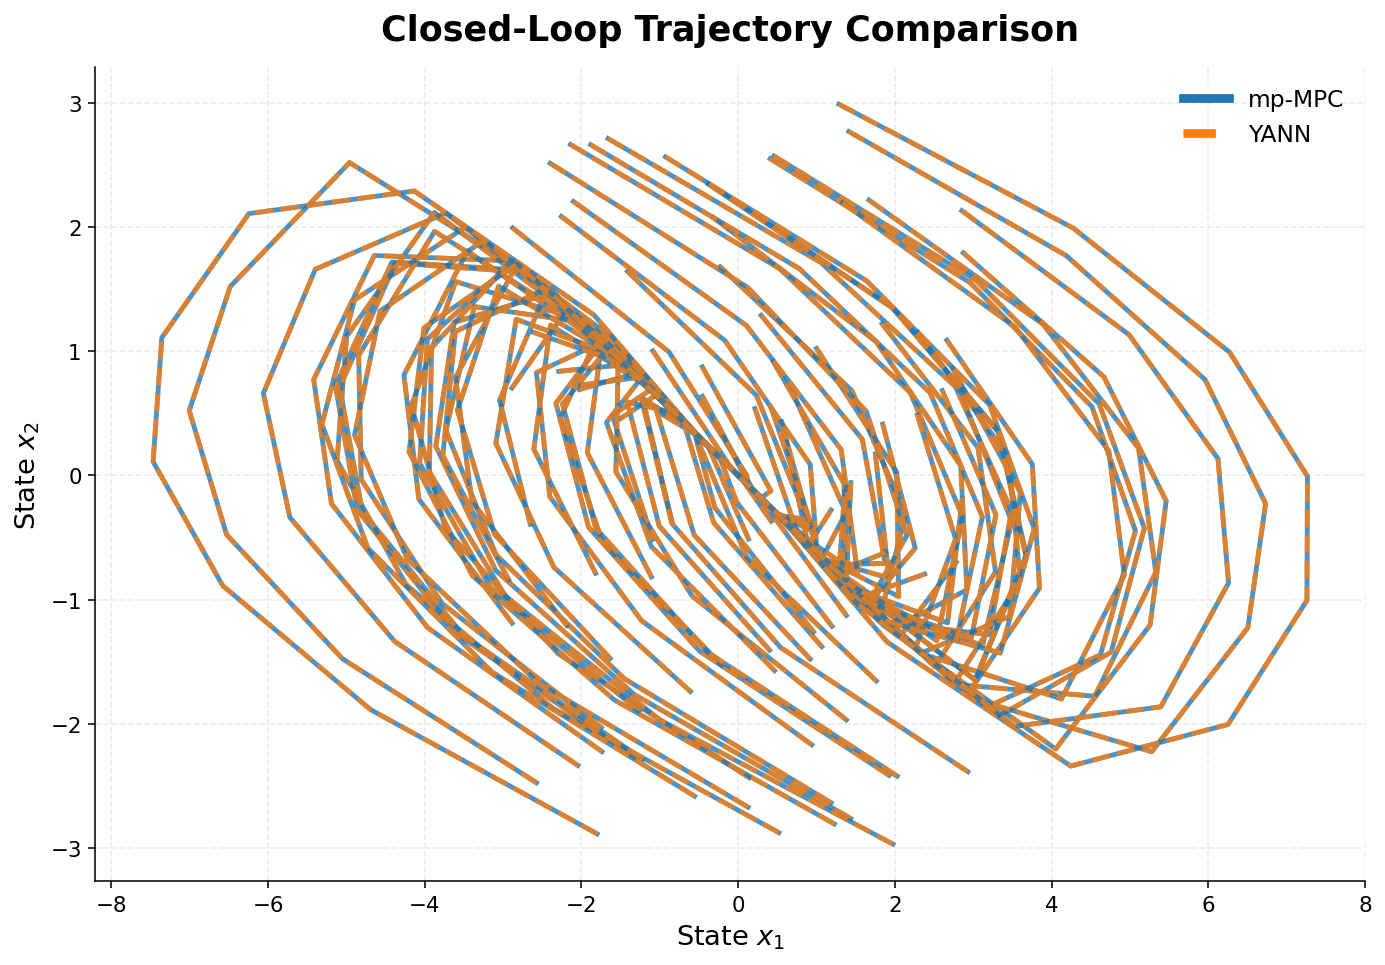

In [9]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 7),
    "figure.dpi": 140,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "axes.labelweight": "medium",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 12,
    "lines.linewidth": 2.0,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})

# Setup
np.random.seed(0)
num_trials = 100
T = 20

# Random initial conditions in a bounded region
initial_conditions = np.random.uniform(
    low=[-3.0, -3.0],
    high=[3.0, 3.0],
    size=(num_trials, 2)
)


# Plot state-space trajectories
fig, ax = plt.subplots()

for x_init in initial_conditions:

    x0 = x_init.reshape(2,1)

    traj_mpc = [x0.flatten()]
    traj_yann = [x0.flatten()]

    x_mpc = x0.copy()
    x_yann = x0.copy()

    for _ in range(T):

        u_eval = solution_example_1.evaluate(x_mpc)
        if u_eval is None:
            break

        u_mpc = np.array(u_eval[0]).reshape(1,1)
        u_yann = np.array(model(x_yann.reshape(1,2))).reshape(1,1)

        x_mpc = A @ x_mpc + B @ u_mpc
        x_yann = A @ x_yann + B @ u_yann

        traj_mpc.append(x_mpc.flatten())
        traj_yann.append(x_yann.flatten())

    traj_mpc = np.array(traj_mpc)
    traj_yann = np.array(traj_yann)

    # mp-MPC
    ax.plot(
        traj_mpc[:,0],
        traj_mpc[:,1],
        color="#1f77b4",
        alpha=0.8,
        linewidth=2.5
    )

    # YANN
    ax.plot(
        traj_yann[:,0],
        traj_yann[:,1],
        color="#ff7f0e",
        linestyle="--",
        alpha=0.8,
        linewidth=2.5
    )

# clean legend
ax.plot([], [], color="#1f77b4", linewidth=4.5, label="mp-MPC")
ax.plot([], [], color="#ff7f0e", linestyle="--", linewidth=4.5, label="YANN")

ax.set_title("Closed-Loop Trajectory Comparison", pad=14)
ax.set_xlabel("State $x_1$")
ax.set_ylabel("State $x_2$")
ax.grid(True)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

# Takeaways

- YANNs provide a structured neural representation of explicit MPC solution maps
- The approximation error arises from numerical computing precision
- For closed-loop trajectories both controllers give identical performance